#### Leaky Integrate and Fire Model (Non-Fractional)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

%matplotlib widget

In [2]:
class LeakyIntegrateAndFireModel():
    """"
    Non-Fractional Leaky Integrate and Fire Model
    """

    def __init__(self, dt: float, time_constant: float, bias: float = 0.0,
                 threshold_voltage: float = 20.0, reset_voltage: float = 0.0, membrane_resistance: float = 10, refractory: float = 5) -> None:
        self.dt = dt
        self.time_constant = time_constant
        self.bias = bias
        self.threshold_voltage = threshold_voltage
        self.reset_voltage = reset_voltage
        self.voltage = 0
        self.spike_state = False
        self.membrane_resistance = membrane_resistance # Unit: MΩ
        self.voltages = []
        self.spike_times = []
        self.spike_voltages = []
        self.refractory = refractory # Unit: ms

    def update_voltage(self, input_current: float, dt: float, t: float) -> None:
        """
        Equation for V_n+1: V_n + (dt/tau)[-V_n + (bias + Rm*I_n)]

        :return: None
        """
        if self.spike_state:
            self.spike_times.append(t)
            self.spike_voltages.append(self.voltage)
            self.voltage = self.reset_voltage
            self.voltages.append(self.voltage)
        elif self.spike_times and (t - self.spike_times[-1] <= self.refractory):
                self.voltages.append(self.voltage)
                return
        else:
            self.voltage = self.voltage + (dt/self.time_constant) * (-self.voltage + (self.bias + self.membrane_resistance * input_current))
            self.voltages.append(self.voltage)

        self.update_spike_state()

    def update_spike_state(self):
        self.spike_state = self.voltage >= self.threshold_voltage

In [3]:
LIF_model = LeakyIntegrateAndFireModel(0.10, 100)

time = 50 * 1000
frequency = 0.5

timestamps = np.arange(0, time, LIF_model.dt)

I = 2.1
I_app = I * np.ones(len(timestamps))

for i, t in enumerate(timestamps):
    LIF_model.update_voltage(I_app[i], LIF_model.dt, t)

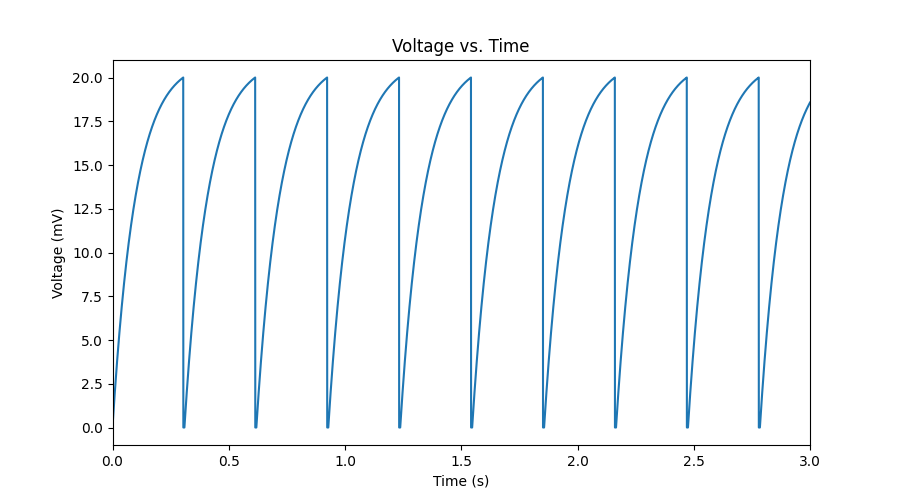

In [4]:
plt.figure(figsize=(9, 5))
plt.ylabel("Voltage (mV)")
plt.xlabel("Time (s)")
plt.title("Voltage vs. Time")
plt.xlim(0, 3)
plt.plot(timestamps/1000, LIF_model.voltages)

In [5]:
plt.plot(np.asarray(LIF_model.spike_times)/1000, LIF_model.spike_voltages, '.')
plt.xlim(0, 4)

(0.0, 4.0)

In [6]:
LIF_model.time_constant

100

In [7]:
plt.plot(LIF_model.voltages[:20000])

In [8]:
I_min, I_max = 5, 15
I_app = I_min + (I_max - I_min) * 0.5 * (1+ np.sin(2*np.pi*timestamps*frequency/1000))

LIF_model = LeakyIntegrateAndFireModel(0.10, 10)

for i, t in enumerate(timestamps):
    LIF_model.update_voltage(I_app[i], LIF_model.dt, t)

In [9]:
plot_x_limit = 0.025

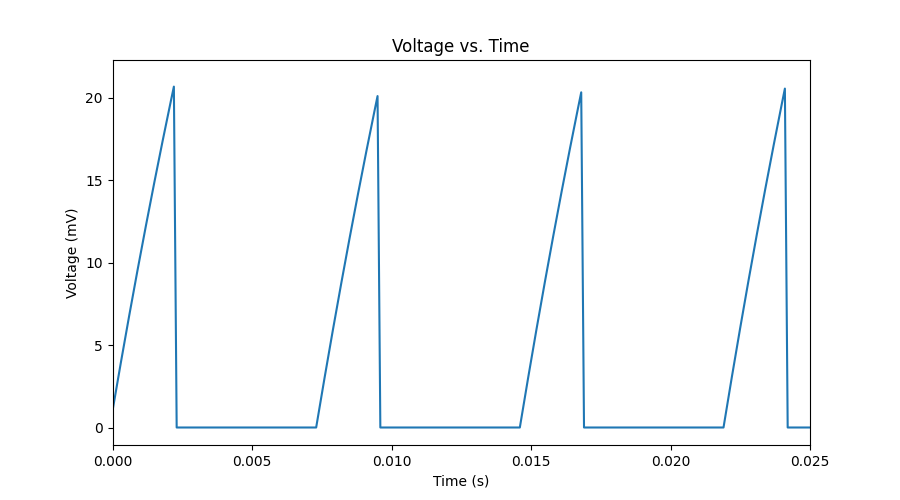

In [10]:
plt.figure(figsize=(9, 5))
plt.ylabel("Voltage (mV)")
plt.xlabel("Time (s)")
plt.title("Voltage vs. Time")
plt.xlim(0, plot_x_limit)
plt.plot(timestamps/1000, LIF_model.voltages)

#### Gaussian White Noise

In [11]:
# Gaussian white noise with the Box-Muller transformation
np.random.seed(42)
random_sample_1 = np.random.random_sample(len(I_app))
random_sample_2 = np.random.random_sample(len(I_app))

# Standard normally distributed random variables
z_0 = np.sqrt(-2 * np.log(random_sample_1)) * np.cos(2*np.pi*random_sample_2)
z_1 = np.sqrt(-2 * np.log(random_sample_1)) * np.sin(2*np.pi*random_sample_2)

In [12]:
plt.hist(z_0, bins = 1000); # Normally distributed

In [13]:
I_app_std_dev = np.std(I_app)
I_app_mean = np.mean(I_app)
noise_0 = z_0 * I_app_std_dev
noise_1 = z_1 * I_app_std_dev

I_app_gaussian_noise = I_app + noise_0

In [14]:
# Before noise:
I_app[:10]

array([10.        , 10.0015708 , 10.00314159, 10.00471239, 10.00628318,
       10.00785398, 10.00942477, 10.01099557, 10.01256636, 10.01413715])

In [15]:
#After noise
I_app_gaussian_noise[:10]

array([ 8.49521218,  8.87949785,  8.27679301, 13.58180918,  7.7129322 ,
        3.25374261,  3.08202126,  9.36634274, 11.63795541,  9.13161229])

In [16]:
LIF_model = LeakyIntegrateAndFireModel(0.10, 10)

for i, t in enumerate(timestamps):
    LIF_model.update_voltage(I_app_gaussian_noise[i], LIF_model.dt, t)

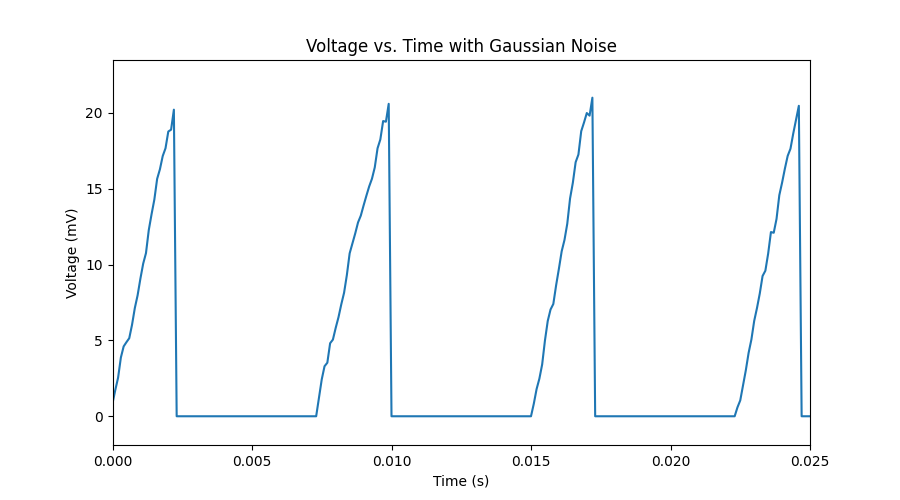

In [17]:
plt.figure(figsize=(9, 5))
plt.ylabel("Voltage (mV)")
plt.xlabel("Time (s)")
plt.title("Voltage vs. Time with Gaussian Noise")
plt.xlim(0, plot_x_limit)
plt.plot(timestamps/1000, LIF_model.voltages)

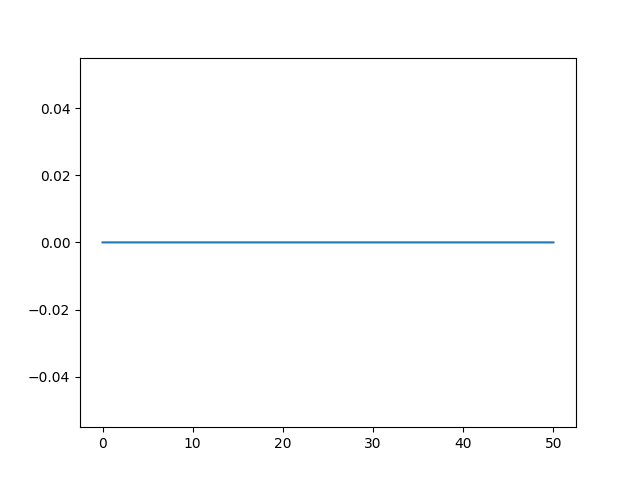

In [18]:
LIF_model = LeakyIntegrateAndFireModel(0.10, 10)

fig, ax = plt.subplots()
animation_voltages = np.zeros(timestamps.shape[0])
line, = ax.plot(timestamps/1000, animation_voltages)
# line.figure(figsize=(9, 5))
# plt.ylabel("Voltage (mV)")
# plt.xlabel("Time (s)")
# plt.title("Voltage vs. Time with Gaussian Noise")
# plt.xlim(0, plot_x_limit)

In [19]:
# def run(i):
#     LIF_model.update_voltage(I_app_gaussian_noise[i], LIF_model.dt, timestamps[i])
#     animation_voltages[i] = LIF_model.voltage
#     line.set_ydata(animation_voltages)
#     return line,
#
# ani = animation.FuncAnimation(fig, run, interval=20, blit=True, save_count=50)